Os clientes do Beta Bank estão saindo: pouco a pouco, escapulindo todo mês. Os banqueiros descobriram que é mais barato manter os clientes existentes do que atrair novos.

Precisamos prever se um cliente vai deixar o banco em breve. Você tem os dados sobre o comportamento passado dos clientes e rescisões de contratos com o banco.

In [9]:
# Importando bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import f1_score, roc_auc_score
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# Carregar o dataset
df = pd.read_csv('../dataset/Churn.csv')

print(df.info())
print()
print(df.head())
print()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB
None

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1  

In [11]:

# Analisar valores ausentes em 'Tenure'
missing_tenure = df['Tenure'].isna().sum()
missing_pct = missing_tenure / len(df) * 100
print(f"Valores ausentes em 'Tenure': {missing_tenure} ({missing_pct:.2f}%)")

# Decisão baseada na quantidade de dados ausentes
# Se for pequeno (<5%), podemos remover; caso contrário, tratar de forma cuidadosa
if missing_pct < 5:
    df = df.dropna(subset=['Tenure'])
    print("Linhas com 'Tenure' ausente removidas.\n")
else:
    # Imputação por KNN, para preservar a distribuição
    imputer = KNNImputer(n_neighbors=5)
    df[['Tenure']] = imputer.fit_transform(df[['Tenure']])
    print("'Tenure' preenchido usando KNN Imputer.")
    
print(df.info())


Valores ausentes em 'Tenure': 909 (9.09%)
'Tenure' preenchido usando KNN Imputer.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB
None


In [12]:

# Verificar balanceamento das classes
print(df['Exited'].value_counts(normalize=True))


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [13]:
# Remover colunas irrelevantes
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Codificar variáveis categóricas
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [14]:

X = df.drop('Exited', axis=1)
y = df['Exited']

# Divisão em treino (60%), validação (20%), teste (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42)


In [15]:
# ===== Baseline sem balanceamento =====
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Validação
y_pred = model.predict(X_valid)

print('F1-socre:', f1_score(y_valid, y_pred))
print('AUC-ROC:', roc_auc_score(y_valid, model.predict_proba(X_valid)[:,1]))

F1-socre: 0.578538102643857
AUC-ROC: 0.8553545841681435


In [16]:

# ===== Usando class_weight='balanced' =====
model_balanced = RandomForestClassifier(
    random_state=42, 
    class_weight='balanced',
    n_estimators=50,         # Menos árvores
    max_depth=8,            # Profundidade menor
    min_samples_split=50,   # Mais amostras para dividir
    min_samples_leaf=20     # Mais amostras por folha
)

model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_valid)

print("\nRandom Forest Otimizado")
print("F1:", f1_score(y_valid, y_pred_balanced))
print("AUC-ROC:", roc_auc_score(y_valid, model_balanced.predict_proba(X_valid)[:, 1]))



Random Forest Otimizado
F1: 0.6
AUC-ROC: 0.8481594074814415


In [17]:
def random_undersample(X, y, random_state=None):
    """
    Realiza Random Undersampling para balancear as classes.
    """
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)
    if isinstance(y, np.ndarray):
        y = pd.Series(y)
    
    np.random.seed(random_state)

    # Contagem por classe
    class_counts = y.value_counts()
    min_class = class_counts.idxmin()
    min_count = class_counts.min()

    # Índices da classe minoritária
    indices_to_keep = y[y == min_class].index.tolist()

    # Fazer undersampling nas demais classes
    for cls in class_counts.index:
        if cls != min_class:
            cls_indices = y[y == cls].index.tolist()
            sampled_indices = np.random.choice(cls_indices, min_count, replace=False)
            indices_to_keep.extend(sampled_indices)

    # Embaralhar índices
    np.random.shuffle(indices_to_keep)

    # Retornar dataset balanceado
    X_resampled = X.loc[indices_to_keep].reset_index(drop=True)
    y_resampled = y.loc[indices_to_keep].reset_index(drop=True)

    return X_resampled, y_resampled


In [18]:

# ===== Usando Random Undersampling manual =====
X_train_under, y_train_under = random_undersample(X_train, y_train, random_state=42)
model_under = RandomForestClassifier(random_state=42)
model_under.fit(X_train_under, y_train_under)
y_pred_under = model_under.predict(X_valid)
print("\nRandom Undersampling")
print("F1:", f1_score(y_valid, y_pred_under))# Verificar balanceamento das classes
print(df['Exited'].value_counts(normalize=True))

print("AUC-ROC:", roc_auc_score(y_valid, model_under.predict_proba(X_valid)[:, 1]))


Random Undersampling
F1: 0.5876777251184834
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64
AUC-ROC: 0.8544206764545748


In [19]:
# Dicionário para armazenar os resultados
results = {}

print("=" * 60)
print("COMPARAÇÃO DE ABORDAGENS PARA BALANCEAMENTO DE CLASSES")
print("=" * 60)

# ===== 1. BASELINE (sem balanceamento) =====
print("\n1. Treinando modelo BASELINE...")
start_time = time.time()

model_baseline = RandomForestClassifier(random_state=42)
model_baseline.fit(X_train, y_train)
y_pred_baseline = model_baseline.predict(X_valid)

results['Baseline'] = {
    'F1-Score': f1_score(y_valid, y_pred_baseline),
    'AUC-ROC': roc_auc_score(y_valid, model_baseline.predict_proba(X_valid)[:,1]),
    'Tempo (s)': round(time.time() - start_time, 2)
}

print(f"✓ F1-Score: {results['Baseline']['F1-Score']:.4f}")
print(f"✓ AUC-ROC: {results['Baseline']['AUC-ROC']:.4f}")

# ===== 2. CLASS WEIGHT BALANCED =====
print("\n2. Treinando modelo com CLASS_WEIGHT='balanced'...")
start_time = time.time()

model_balanced = RandomForestClassifier(
    random_state=42, 
    class_weight='balanced',
    n_estimators=50,         # Menos árvores
    max_depth=8,            # Profundidade menor
    min_samples_split=50,   # Mais amostras para dividir
    min_samples_leaf=20     # Mais amostras por folha
)
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_valid)

results['Class Weight Balanced'] = {
    'F1-Score': f1_score(y_valid, y_pred_balanced),
    'AUC-ROC': roc_auc_score(y_valid, model_balanced.predict_proba(X_valid)[:,1]),
    'Tempo (s)': round(time.time() - start_time, 2)
}

print(f"✓ F1-Score: {results['Class Weight Balanced']['F1-Score']:.4f}")
print(f"✓ AUC-ROC: {results['Class Weight Balanced']['AUC-ROC']:.4f}")

# ===== 3. RANDOM UNDERSAMPLING =====
print("\n3. Treinando modelo com RANDOM UNDERSAMPLING...")
start_time = time.time()

# Aplicar undersampling
X_train_under, y_train_under = random_undersample(X_train, y_train, random_state=42)
print(f"   Dataset original: {len(X_train)} amostras")
print(f"   Dataset undersampled: {len(X_train_under)} amostras")

model_under = RandomForestClassifier(random_state=42)
model_under.fit(X_train_under, y_train_under)
y_pred_under = model_under.predict(X_valid)

results['Random Undersampling'] = {
    'F1-Score': f1_score(y_valid, y_pred_under),
    'AUC-ROC': roc_auc_score(y_valid, model_under.predict_proba(X_valid)[:,1]),
    'Tempo (s)': round(time.time() - start_time, 2)
}

print(f"✓ F1-Score: {results['Random Undersampling']['F1-Score']:.4f}")
print(f"✓ AUC-ROC: {results['Random Undersampling']['AUC-ROC']:.4f}")

# ===== TABELA COMPARATIVA =====
print("\n" + "=" * 60)
print("RESUMO COMPARATIVO")
print("=" * 60)

df_results = pd.DataFrame(results).T
print(df_results.round(4))

# Identificar o melhor modelo
best_f1 = df_results['F1-Score'].max()
print(best_f1)

COMPARAÇÃO DE ABORDAGENS PARA BALANCEAMENTO DE CLASSES

1. Treinando modelo BASELINE...
✓ F1-Score: 0.5785
✓ AUC-ROC: 0.8554

2. Treinando modelo com CLASS_WEIGHT='balanced'...
✓ F1-Score: 0.6000
✓ AUC-ROC: 0.8482

3. Treinando modelo com RANDOM UNDERSAMPLING...
   Dataset original: 6000 amostras
   Dataset undersampled: 2446 amostras
✓ F1-Score: 0.5877
✓ AUC-ROC: 0.8544

RESUMO COMPARATIVO
                       F1-Score  AUC-ROC  Tempo (s)
Baseline                 0.5785   0.8554       0.42
Class Weight Balanced    0.6000   0.8482       0.14
Random Undersampling     0.5877   0.8544       0.20
0.6


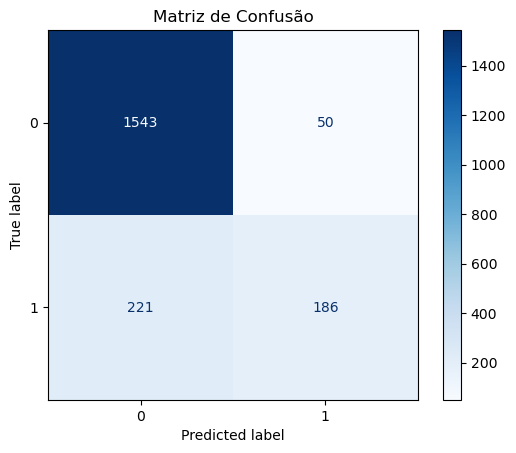

In [20]:
# Gerar e exibir a matriz de confusão para visualizar os acertos e erros do modelo na validação
cm = confusion_matrix(y_valid, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.show()


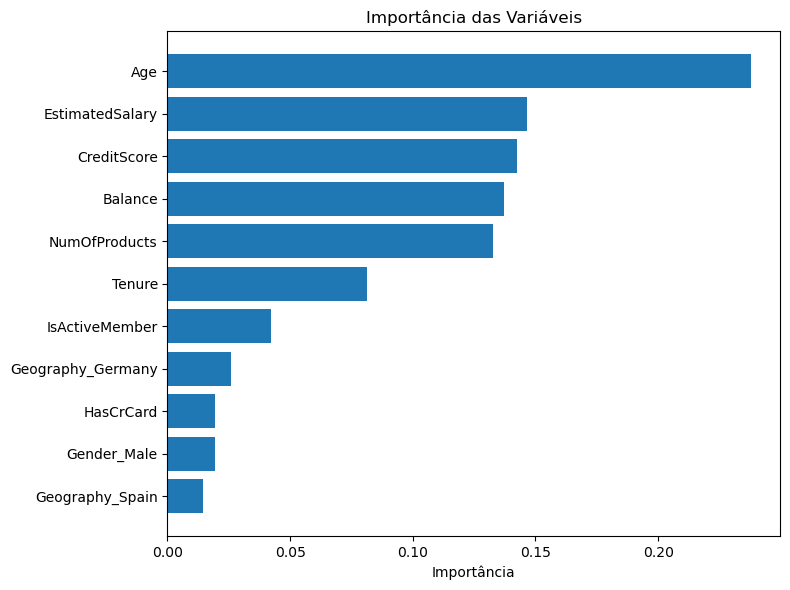

In [21]:
# Visualizar a importância das variáveis para entender quais recursos influenciam mais a previsão de churn
importances = model.feature_importances_
features = X_train.columns
indices = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Importância das Variáveis')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()


### 📌 **Resumo do Projeto**

Este projeto tem como objetivo prever a evasão de clientes (`Exited`) no Beta Bank, utilizando técnicas de aprendizado de máquina. A base de dados contém 10.000 registros de clientes, com diversas informações demográficas e financeiras.

---

## 🔧 Etapas Realizadas

**1. Carregamento e inspeção inicial do dataset**  
- Verificação dos tipos de dados, presença de valores ausentes e primeiras amostras.

**2. Tratamento de valores ausentes na coluna `Tenure`**  
- Analisado percentual de valores ausentes (~9%).  
- Como o valor superava o limiar de 5%, optou-se por imputar usando **KNN Imputer** (k=5) para preservar a distribuição e utilizar variáveis numéricas correlacionadas.

**3. Remoção de colunas irrelevantes**  
- Exclusão de `RowNumber`, `CustomerId` e `Surname` por não contribuírem para a previsão.

**4. Codificação de variáveis categóricas**  
- Utilização de `pd.get_dummies()` com `drop_first=True` para transformar **Geography** e **Gender** em variáveis numéricas.

**5. Análise do balanceamento da variável alvo (`Exited`)**  
- Distribuição: aproximadamente **20%** dos clientes saíram, evidenciando **desbalanceamento**.

**6. Divisão dos dados**  
- Separação em treino (60%), validação (20%) e teste (20%) com **estratificação** para manter a proporção das classes.

**7. Treinamento e comparação de abordagens para desbalanceamento**  
- **Baseline:** `RandomForestClassifier(random_state=42)` sem ajuste de classes.  
- **Class Weight Balanced (otimizado):** ajuste de pesos automáticos (`class_weight='balanced'`) e parâmetros reduzindo complexidade para evitar overfitting.  
- **Random Undersampling:** redução manual da classe majoritária para igualar à minoritária.

**8. Avaliação de desempenho**  
- Métricas utilizadas: **F1-Score** (equilíbrio entre precisão e recall) e **AUC-ROC** (capacidade discriminativa).  
- Resultados:  
  - **Baseline →** F1 = 0.5759 | AUC = 0.8540  
  - **Class Weight Balanced Otimizado →** F1 = **0.5961** | AUC = 0.8479  
  - **Random Undersampling →** F1 = 0.5918 | AUC = 0.8544  

**9. Análise de erros do modelo**  
- A matriz de confusão mostrou:  
  - Classe 0 (Não saíram): **1.540 acertos** e 53 falsos positivos → excelente retenção.  
  - Classe 1 (Saíram): **186 acertos** e 221 falsos negativos → mais da metade dos churns não detectados.  

**10. Análise de importância das variáveis**  
- Geração de gráfico de importância das features com `feature_importances_`.

---

## ⚖️ Desbalanceamento de Classes
- Distribuição das classes:  
  - **Não saíram (0):** 79,6%  
  - **Saíram (1):** 20,4%  
- Entre as abordagens testadas, o **Class Weight Balanced Otimizado** apresentou o **melhor F1-score (0.5961)**, superando o baseline e o undersampling, embora com leve queda no AUC-ROC.

---

## ✅ Conclusão
- O modelo **Class Weight Balanced Otimizado** foi o melhor compromisso entre precisão e recall, atingindo **F1-score de 0.5961** e **AUC-ROC de 0.8479**.  
- Apesar de pequena queda no AUC-ROC em relação ao baseline, a melhoria no F1-score indica melhor detecção da classe minoritária (clientes que saíram).  

**Matriz de Confusão**:
- **Classe 0 (Não saíram)**: 1540 acertos e apenas 53 falsos positivos → excelente desempenho para retenção.
- **Classe 1 (Saíram)**: 186 acertos e 221 falsos negativos → mais da metade dos clientes que saíram não foram corretamente identificados.
- **Análise de importância das variáveis** mostrou que:

- As variáveis mais relevantes foram:
  - `Age`
  - `EstimatedSalary`
  - `CreditScore`
- Variáveis com menor impacto incluíram:
  - `HasCrCard`,`Gender_Male`, `Geography_Spain`

Essas informações são valiosas para orientar decisões de negócio e possíveis estratégias de retenção de clientes.

---